In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Video segmentation with SAM 2

In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [ ]:
CSV_PATH = "./data/2025-11-20_15-30-11-a3a383b4/fixations.csv"
VIDEO_FPS = 30


df = pd.read_csv(CSV_PATH)

t0 = df["start timestamp [ns]"].min()

df["time_s"] = (df["start timestamp [ns]"] - t0) / 1e9

df["frame"] = (df["time_s"] * VIDEO_FPS).astype(int)

fixations_extracted = df[[
    "fixation id",
    "frame",
    "fixation x [px]",
    "fixation y [px]",
    "duration [ms]"
]].rename(columns={
    "fixation x [px]": "x",
    "fixation y [px]": "y"
})


In [14]:
fixations_extracted.to_csv("fixations_with_frames.csv", index=False)

def get_fixation_triplets(df, max_frame):

    filtered = df[df["frame"] < max_frame]

    triplets = list(
        zip(
            filtered["frame"].astype(int),
            filtered["x"].astype(float),
            filtered["y"].astype(float)
        )
    )

    return triplets

df = pd.read_csv("fixations_with_frames.csv")

triplets = get_fixation_triplets(df, max_frame=1000)

print(triplets)

[(0, 826.055, 167.563), (7, 611.641, 370.053), (13, 743.508, 336.986), (21, 963.856, 385.812), (26, 910.613, 341.267), (42, 583.086, 428.235), (46, 595.326, 395.257), (54, 615.635, 358.522), (63, 743.973, 334.92), (78, 708.091, 311.213), (90, 761.885, 348.014), (101, 756.695, 303.217), (160, 602.63, 374.152), (167, 1088.918, 526.344), (173, 1067.649, 724.867), (178, 924.785, 777.489), (188, 1242.857, 584.869), (193, 1191.988, 554.684), (198, 1282.017, 561.757), (204, 1282.063, 512.478), (211, 1247.899, 495.031), (231, 616.951, 549.725), (237, 588.475, 241.012), (242, 639.86, 295.433), (253, 964.331, 189.026), (263, 482.392, 248.168), (271, 755.126, 519.63), (281, 734.269, 437.269), (295, 830.702, 186.747), (300, 823.078, 237.975), (306, 703.851, 279.61), (314, 847.685, 234.161), (324, 933.987, 283.557), (334, 879.62, 355.762), (347, 754.221, 200.958), (356, 828.445, 366.886), (366, 783.548, 254.818), (386, 829.065, 392.233), (393, 791.782, 316.308), (401, 910.134, 312.813), (410, 832.0

In [15]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


### Loading the SAM 2 video predictor

In [16]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = os.path.abspath("./model/sam2.1_hiera_small.pt")
model_cfg = os.path.abspath("./model/sam2.1_hiera_s.yaml")

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [17]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

#### Select an example video

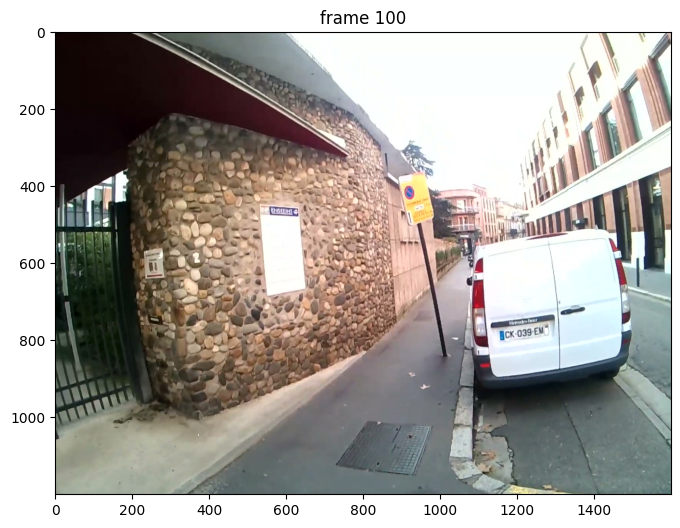

In [18]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "./videos/velo_1"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 100
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

#### Initialize the inference state

In [19]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 1001/1001 [00:27<00:00, 36.61it/s]


In [10]:
predictor.reset_state(inference_state)

In [20]:
ann_obj_id = 0
for ann_frame_idx, x, y in triplets:
    ann_obj_id += 1
    print(f"{ann_obj_id} Adding click at frame {ann_frame_idx}, x={x}, y={y}")
    
    points = np.array([[x, y]], dtype=np.float32)
    # for labels, `1` means positive click and `0` means negative click
    labels = np.array([1], np.int32)
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )

1 Adding click at frame 0, x=826.055, y=167.563


C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


2 Adding click at frame 7, x=611.641, y=370.053
3 Adding click at frame 13, x=743.508, y=336.986
4 Adding click at frame 21, x=963.856, y=385.812
5 Adding click at frame 26, x=910.613, y=341.267
6 Adding click at frame 42, x=583.086, y=428.235
7 Adding click at frame 46, x=595.326, y=395.257
8 Adding click at frame 54, x=615.635, y=358.522
9 Adding click at frame 63, x=743.973, y=334.92
10 Adding click at frame 78, x=708.091, y=311.213
11 Adding click at frame 90, x=761.885, y=348.014
12 Adding click at frame 101, x=756.695, y=303.217
13 Adding click at frame 160, x=602.63, y=374.152
14 Adding click at frame 167, x=1088.918, y=526.344
15 Adding click at frame 173, x=1067.649, y=724.867
16 Adding click at frame 178, x=924.785, y=777.489
17 Adding click at frame 188, x=1242.857, y=584.869
18 Adding click at frame 193, x=1191.988, y=554.684
19 Adding click at frame 198, x=1282.017, y=561.757
20 Adding click at frame 204, x=1282.063, y=512.478
21 Adding click at frame 211, x=1247.899, y=49

In [21]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video:   0%|          | 1/1001 [00:27<7:46:17, 27.98s/it]


KeyboardInterrupt: 

In [13]:
import cv2
import numpy as np
from PIL import Image
import os

# Fonction pour superposer le masque sur l'image
def overlay_mask(image, mask, color=(0, 0, 255), alpha=0.5):
    """
    image: np.array HxWx3
    mask: bool HxW
    """
    # S'assurer que le masque a la bonne forme
    if mask.ndim == 3:
        mask = mask[0]  # parfois c'est (1, H, W)
    if mask.shape != image.shape[:2]:
        # redimensionner le masque si nécessaire
        mask = cv2.resize(mask.astype(np.uint8), (image.shape[1], image.shape[0]))
        mask = mask.astype(bool)
    
    overlay = image.copy()
    overlay[mask] = (np.array(color) * alpha + overlay[mask] * (1 - alpha)).astype(np.uint8)
    return overlay

# Récupérer les dimensions exactes de la première image
img0 = np.array(Image.open(os.path.join(video_dir, frame_names[0])).convert("RGB"))
height, width = img0.shape[:2]

# Paramètres vidéo
video_out_path = "video_with_masks.mp4"
fps = 30
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(video_out_path, fourcc, fps, (width, height))

# Boucle sur toutes les frames
for idx, frame_name in enumerate(frame_names):
    img = np.array(Image.open(os.path.join(video_dir, frame_names[idx])).convert("RGB"))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    if idx in video_segments:
        for out_obj_id, out_mask in video_segments[idx].items():
            img = overlay_mask(img, out_mask)
    
    video_writer.write(img)

video_writer.release()
print(f"Vidéo enregistrée dans {video_out_path}")


Vidéo enregistrée dans video_with_masks.mp4
